In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

In [165]:
df=pd.read_csv("Loan.csv")
df.head()

,Income,Creditscore,Age,Loanamount,Employyears
0,20000,300,21,5000,0
1,50000,850,65,50000,20
2,30000,100,26,100000,100


In [203]:
df['Loan_Approved']=((df['Creditscore']>300)&(df['Income']>25000)).astype(int)
X=df[['Income','Creditscore','Age','Loanamount','Employyears']]
y=df['Loan_Approved']

In [205]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [207]:
model=DecisionTreeClassifier(criterion='gini',max_depth=3)

In [209]:
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [211]:
y_pred=model.predict(X_test)

In [213]:
print("Accuracy score:",accuracy_score(y_test,y_pred))

Accuracy score: 1.0


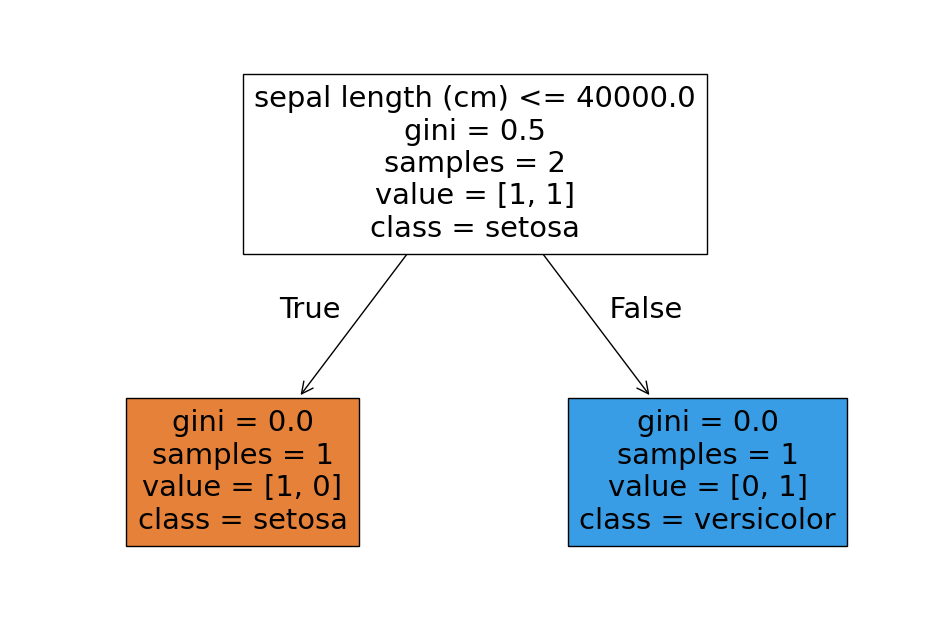

In [217]:
plt.figure(figsize=(12,8))
tree.plot_tree(model,feature_names=iris.feature_names,class_names=iris.target_names,filled=True)
plt.show()

In [219]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [221]:
rf_model=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)

In [223]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [225]:
y_pred=rf_model.predict(X_test)

In [227]:
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred))

Random Forest Accuracy: 1.0


In [229]:
importances=rf_model.feature_importances_

In [231]:
feature_rank=pd.DataFrame({'Feature':X_train.columns,'Importance':importances})
feature_rank=feature_rank.sort_values(by='Importance',ascending=False)
print(feature_rank)

       Feature  Importance
0       Income    0.288462
1  Creditscore    0.250000
3   Loanamount    0.173077
4  Employyears    0.153846
2          Age    0.134615


In [233]:
import pickle
pickle.dump(rf_model,open('loan_model.pkl','wb'))